1_data_exploration

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn_plt

# 1. Load Dataset
print("--- Loading Dataset ---")
train = pd.read_csv('../data/raw/train.csv')

# 2. Basic Dataset Inspection
print("\n--- Shape & Data Types ---")
print(f"Dataset Shape: {train.shape}")
print(train.dtypes)

print("\n--- Missing Values Check ---")
print(train.isnull().sum())

# 3. Scope & Cardinality
print("\n--- Scope & Cardinality ---")
print(f"Date Range: {train['date'].min()} to {train['date'].max()}")
print(f"Total Unique Stores: {train['store_nbr'].nunique()}")
print(f"Total Product Families: {train['family'].nunique()}")

# 4. Target Variable & Feature Distributions
print("\n--- Summary Statistics ---")
print(train[['sales', 'onpromotion']].describe())


--- Loading Dataset ---

--- Shape & Data Types ---
Dataset Shape: (3000888, 6)
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

--- Missing Values Check ---
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

--- Scope & Cardinality ---
Date Range: 2013-01-01 to 2017-08-15
Total Unique Stores: 54
Total Product Families: 33

--- Summary Statistics ---
              sales   onpromotion
count  3.000888e+06  3.000888e+06
mean   3.577757e+02  2.602770e+00
std    1.101998e+03  1.221888e+01
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00
50%    1.100000e+01  0.000000e+00
75%    1.958473e+02  0.000000e+00
max    1.247170e+05  7.410000e+02


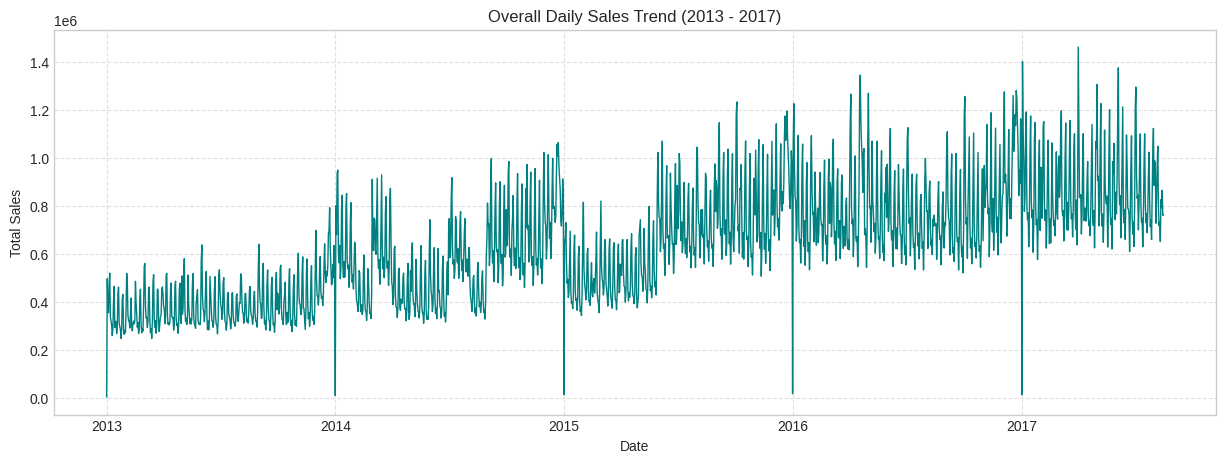

In [53]:
from pathlib import Path
import matplotlib.pyplot as plt

# Ensure reports/figures exists (project root relative, works from notebooks/ or root)
_fig_dir = Path("../reports/figures")
if not _fig_dir.exists():
    _fig_dir = Path("reports/figures")
_fig_dir.mkdir(parents=True, exist_ok=True)

# 5. Quick Visual Trend: Aggregate Daily Sales
train['date'] = pd.to_datetime(train['date'])
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='teal', linewidth=1)
plt.title('Overall Daily Sales Trend (2013 - 2017)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(_fig_dir / "historical_sales.png", dpi=150, bbox_inches='tight')
plt.show()


2. Data Cleaning

In [55]:


def load_and_clean_data(file_path):
    """
    Loads the raw train data, optimizes memory types,
    parses dates, and ensures chronological sorting.
    """
    print("--- Loading Raw Data --")
    df = pd.read_csv(file_path)

    # 1. Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])

    # 2. Sort values chronologically by store, family, and date
    df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

    # 3. Data Cleaning Documentation Check
    # Missing values check: 0 found. No imputation required.
    missing_count = df.isnull().sum().sum()
    print(f"Total missing values found: {missing_count}")
    print("Documentation: No missing value transformations required. Data is clean.")

    # 4. Optimize data types to save memory
    df['store_nbr'] = df['store_nbr'].astype('int8')
    df['onpromotion'] = df['onpromotion'].astype('int32')
    df['sales'] = df['sales'].astype('float32')

    return df

if __name__ == "__main__":
    train_df = load_and_clean_data('../data/raw/train.csv')
    print("Cleaned Data Shape:", train_df.shape)
    print(train_df.head())

--- Loading Raw Data --
Total missing values found: 0
Documentation: No missing value transformations required. Data is clean.
Cleaned Data Shape: (3000888, 6)
     id       date  store_nbr      family  sales  onpromotion
0     0 2013-01-01          1  AUTOMOTIVE    0.0            0
1  1782 2013-01-02          1  AUTOMOTIVE    2.0            0
2  3564 2013-01-03          1  AUTOMOTIVE    3.0            0
3  5346 2013-01-04          1  AUTOMOTIVE    3.0            0
4  7128 2013-01-05          1  AUTOMOTIVE    5.0            0


3: Forecasting Dataset Design & Feature Engineering ---
for proper chronological sorting per store and family

In [56]:


train_df = train_df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# 1. Calendar Features
train_df['year'] = train_df['date'].dt.year.astype('int16')
train_df['month'] = train_df['date'].dt.month.astype('int8')
train_df['day'] = train_df['date'].dt.day.astype('int8')
train_df['dayofweek'] = train_df['date'].dt.dayofweek.astype('int8')
train_df['week'] = train_df['date'].dt.isocalendar().week.astype('int8')
train_df['quarter'] = train_df['date'].dt.quarter.astype('int8')
train_df['is_weekend'] = train_df['dayofweek'].isin([5, 6]).astype('int8')

# 2. Historical Lags (grouped by store and family to respect series boundaries)
group_cols = ['store_nbr', 'family']
train_df['lag_1'] = train_df.groupby(group_cols)['sales'].shift(1)
train_df['lag_7'] = train_df.groupby(group_cols)['sales'].shift(7)
train_df['lag_14'] = train_df.groupby(group_cols)['sales'].shift(14)

# 3. Rolling Statistics (shifted by 1 to prevent data leakage)
train_df['rolling_mean_7'] = train_df.groupby(group_cols)['sales'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

# 4. Handle initial missing values safely
train_df['lag_1'] = train_df['lag_1'].fillna(0)
train_df['lag_7'] = train_df['lag_7'].fillna(0)
train_df['lag_14'] = train_df['lag_14'].fillna(0)
train_df['rolling_mean_7'] = train_df['rolling_mean_7'].fillna(0)

4: Time-Based Validation.

In [59]:
print("---  4: Time-Based Validation Split ---")

# Define a chronological cutoff date for validation
# Let's use the final month of the training data (e.g., July/August 2017)
# train_df['date'].max() is typically 2017-08-15 for this dataset
cutoff_date = pd.to_datetime('2017-08-01')

print(f"Validation Cutoff Date: {cutoff_date}")

# Split into train and validation sets chronologically
train_data = train_df[train_df['date'] < cutoff_date].copy()
val_data = train_df[train_df['date'] >= cutoff_date].copy()

print(f"Training set shape: {train_data.shape}")
print(f"Validation set shape: {val_data.shape}")

# Define features and target variable for modeling
# We exclude 'id', 'date', and 'sales' (target) from features
features = [
    'store_nbr', 'family', 'onpromotion',
    'year', 'month', 'day', 'dayofweek', 'week', 'quarter', 'is_weekend',
    'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7'
]
target = 'sales'

print(f"Selected Features ({len(features)}): {features}")

---  4: Time-Based Validation Split ---
Validation Cutoff Date: 2017-08-01 00:00:00
Training set shape: (2974158, 17)
Validation set shape: (26730, 17)
Selected Features (14): ['store_nbr', 'family', 'onpromotion', 'year', 'month', 'day', 'dayofweek', 'week', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7']


5: Baselines- to set up our benchmark models before training

In [60]:
print("--- 5: Building Baselines ---")

# Let's create a validation copy to evaluate our baselines
val_eval = val_data.copy()

# 1. Baseline 1: Naive Forecast (Prediction = previous day's sales, i.e., lag_1)
# Since lag_1 is already engineered, we can use it directly as our naive prediction!
val_eval['pred_naive'] = val_eval['lag_1']

# 2. Baseline 2: Seasonal Naive Forecast (Prediction = sales from 7 days ago, i.e., lag_7)
val_eval['pred_seasonal_naive'] = val_eval['lag_7']

# Evaluation Metric Functions
def evaluate_metrics(y_true, y_pred):
    """Calculates MAE, RMSE, and WAPE."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # WAPE: Weighted Absolute Percentage Error
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) if np.sum(y_true) != 0 else 0

    return {'MAE': mae, 'RMSE': rmse, 'WAPE': wape}

# Evaluate Naive Baseline
naive_metrics = evaluate_metrics(val_eval['sales'], val_eval['pred_naive'])
print("\n--- Naive Baseline Performance ---")
for metric, val in naive_metrics.items():
    print(f"{metric}: {val:.4f}")

# Evaluate Seasonal Naive Baseline
seasonal_metrics = evaluate_metrics(val_eval['sales'], val_eval['pred_seasonal_naive'])
print("\n--- Seasonal Naive Baseline Performance ---")
for metric, val in seasonal_metrics.items():
    print(f"{metric}: {val:.4f}")

--- 5: Building Baselines ---

--- Naive Baseline Performance ---
MAE: 108.3883
RMSE: 368.7987
WAPE: 0.2330

--- Seasonal Naive Baseline Performance ---
MAE: 101.2522
RMSE: 353.8006
WAPE: 0.2177


In [42]:
print("---  6: Machine Learning Model (Ridge Regression) ---")
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Prepare features and target
# We use pd.get_dummies to handle the categorical 'family' column
X_train = pd.get_dummies(train_data[features], columns=['family'], drop_first=True)
y_train = train_data[target]

X_val = pd.get_dummies(val_data[features], columns=['family'], drop_first=True)
y_val = val_data[target]

# Align columns to ensure train and validation sets match perfectly
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

# 2. Build Pipeline (Scaling + Ridge Regression)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

print("Training Ridge Regression model...")
model.fit(X_train, y_train)

# 3. Predict and clip negative values to 0
val_preds = model.predict(X_val)
val_preds = np.clip(val_preds, 0, None)

# 4. Evaluate
ml_metrics = evaluate_metrics(y_val, val_preds)
print("\n--- Ridge Regression Performance ---")
for metric, val in ml_metrics.items():
    print(f"{metric}: {val:.4f}")

# 5. Quick Comparison against Seasonal Naive
print("\n--- Benchmark Comparison (WAPE) ---")
print(f"Seasonal Naive WAPE: {seasonal_metrics['WAPE']:.4f}")
print(f"Ridge Regression WAPE: {ml_metrics['WAPE']:.4f}")

--- Starting Phase 6: Machine Learning Model (Ridge Regression) ---
Training Ridge Regression model...

--- Ridge Regression Performance ---
MAE: 86.2559
RMSE: 250.6917
WAPE: 0.1854

--- Benchmark Comparison (WAPE) ---
Seasonal Naive WAPE: 0.2177
Ridge Regression WAPE: 0.1854


In [43]:
print("--- Starting Phase 7: Error Analysis ---")

# 1. Attach predictions and calculate absolute errors on the validation evaluation DataFrame
val_eval = val_data.copy()
val_eval['pred_ridge'] = val_preds
val_eval['abs_error'] = np.abs(val_eval['sales'] - val_eval['pred_ridge'])

# 2. Analyze errors by Product Family
family_errors = val_eval.groupby('family')['abs_error'].mean().reset_index()
family_errors = family_errors.sort_values(by='abs_error', ascending=False)
print("\n--- Top 5 Product Families with Highest Average Error ---")
print(family_errors.head(5))

# 3. Analyze errors by Store Number
store_errors = val_eval.groupby('store_nbr')['abs_error'].mean().reset_index()
store_errors = store_errors.sort_values(by='abs_error', ascending=False)
print("\n--- Top 5 Stores with Highest Average Error ---")
print(store_errors.head(5))

# 4. Analyze errors over Time (Daily average absolute error)
daily_errors = val_eval.groupby('date')['abs_error'].mean().reset_index()
worst_days = daily_errors.sort_values(by='abs_error', ascending=False)
print("\n--- Top 5 Dates with Highest Average Error ---")
print(worst_days.head(5))

--- Starting Phase 7: Error Analysis ---

--- Top 5 Product Families with Highest Average Error ---
       family   abs_error
12  GROCERY I  669.870126
3   BEVERAGES  563.818840
7    CLEANING  341.392264
30    PRODUCE  290.490385
8       DAIRY  124.316598

--- Top 5 Stores with Highest Average Error ---
    store_nbr   abs_error
43         44  176.290686
46         47  164.291732
47         48  163.696681
44         45  160.225809
45         46  153.136662

--- Top 5 Dates with Highest Average Error ---
         date   abs_error
11 2017-08-12  127.443134
0  2017-08-01  117.042802
5  2017-08-06  100.782760
12 2017-08-13   99.274257
7  2017-08-08   93.578779


In [44]:
print("--- Starting Phase 8: Final Model Selection & Retraining ---")

# 1. Select Ridge Regression based on performance, speed, and interpretability
# 2. Combine train and validation data to train on the maximum available history
train_full = train_df.copy()

X_full = pd.get_dummies(train_full[features], columns=['family'], drop_first=True)
y_full = train_full[target]

# Initialize and fit the final pipeline on the full dataset
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

print("Retraining final Ridge Regression model on full historical dataset...")
final_model.fit(X_full, y_full)
print("Final model successfully trained and ready for forecasting!")

--- Starting Phase 8: Final Model Selection & Retraining ---
Retraining final Ridge Regression model on full historical dataset...
Final model successfully trained and ready for forecasting!


In [ ]:
# Load test data for forecasting
test_df = pd.read_csv('../data/raw/test.csv')
test_df['date'] = pd.to_datetime(test_df['date'])
test_df = test_df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
print(f"Test data loaded: {test_df.shape}")
print(test_df.head())

In [45]:
print("--- Starting Phase 9 (Corrected): Recursive 15-Day Forecasting ---")

# 1. Sort test_df chronologically and get unique forecast dates
test_df = test_df.sort_values('date').reset_index(drop=True)
test_dates = test_df['date'].unique()

# 2. Set up a working history buffer containing the tail end of train_df
# (We need at least the last 14 days to compute lag_14 accurately)
max_train_date = train_df['date'].max()
work_history = train_df[train_df['date'] >= (max_train_date - pd.Timedelta(days=30))][
    ['date', 'store_nbr', 'family', 'sales', 'onpromotion']
].copy()

test_preds_recursive = []

# 3. Iterate day-by-day through the 15-day forecast horizon
for current_date in test_dates:
    # Filter test rows for the specific current date
    sub_test = test_df[test_df['date'] == current_date].copy()

    # Define time offsets for dynamic lag lookup from our work_history buffer
    lag1_date = current_date - pd.Timedelta(days=1)
    lag7_date = current_date - pd.Timedelta(days=7)
    lag14_date = current_date - pd.Timedelta(days=14)
    roll_start_date = current_date - pd.Timedelta(days=7)
    roll_end_date = current_date - pd.Timedelta(days=1)

    # Map dynamic lag values from work_history (which now includes prior day predictions)
    l1 = work_history[work_history['date'] == lag1_date].set_index(['store_nbr', 'family'])['sales']
    l7 = work_history[work_history['date'] == lag7_date].set_index(['store_nbr', 'family'])['sales']
    l14 = work_history[work_history['date'] == lag14_date].set_index(['store_nbr', 'family'])['sales']

    roll_subset = work_history[(work_history['date'] >= roll_start_date) & (work_history['date'] <= roll_end_date)]
    roll_mean = roll_subset.groupby(['store_nbr', 'family'])['sales'].mean()

    sub_test['lag_1'] = sub_test.set_index(['store_nbr', 'family']).index.map(l1).values
    sub_test['lag_7'] = sub_test.set_index(['store_nbr', 'family']).index.map(l7).values
    sub_test['lag_14'] = sub_test.set_index(['store_nbr', 'family']).index.map(l14).values
    sub_test['rolling_mean_7'] = sub_test.set_index(['store_nbr', 'family']).index.map(roll_mean).values

    # Handle any cold-start NaNs by filling with 0
    sub_test['lag_1'] = sub_test['lag_1'].fillna(0)
    sub_test['lag_7'] = sub_test['lag_7'].fillna(0)
    sub_test['lag_14'] = sub_test['lag_14'].fillna(0)
    sub_test['rolling_mean_7'] = sub_test['rolling_mean_7'].fillna(0)

    # Prepare features matching the training columns structure
    X_sub = pd.get_dummies(sub_test[features], columns=['family'], drop_first=True)
    X_sub = X_sub.reindex(columns=X_full.columns, fill_value=0)

    # Generate predictions for this day
    preds = final_model.predict(X_sub)
    preds = np.clip(preds, 0, None)  # Clip negative sales to 0

    # Store predictions
    sub_test['sales'] = preds
    test_preds_recursive.extend(preds)

    # FEEDBACK LOOP: Append today's predictions into work_history so tomorrow can use them as lags!
    new_rows = sub_test[['date', 'store_nbr', 'family', 'sales', 'onpromotion']].copy()
    work_history = pd.concat([work_history, new_rows], ignore_index=True)

# 4. Save the corrected recursive submission file
test_df['sales'] = test_preds_recursive
submission = test_df[['id', 'sales']]
submission.to_csv('submission.csv', index=False)

print("Recursive forecasting complete! Updated 'submission.csv' generated successfully.")
print(submission.head(10))

--- Starting Phase 9 (Corrected): Recursive 15-Day Forecasting ---
Recursive forecasting complete! Updated 'submission.csv' generated successfully.
        id        sales
0  3000888     0.000000
1  3001778     0.000000
2  3000890     0.000000
3  3000891  2210.519565
4  3000892     0.000000
5  3000893   367.390630
6  3000894     0.000000
7  3000895   746.768320
8  3000896   823.425889
9  3000897   136.238237


--- Starting Phase 10: Business Visualization & Story ---


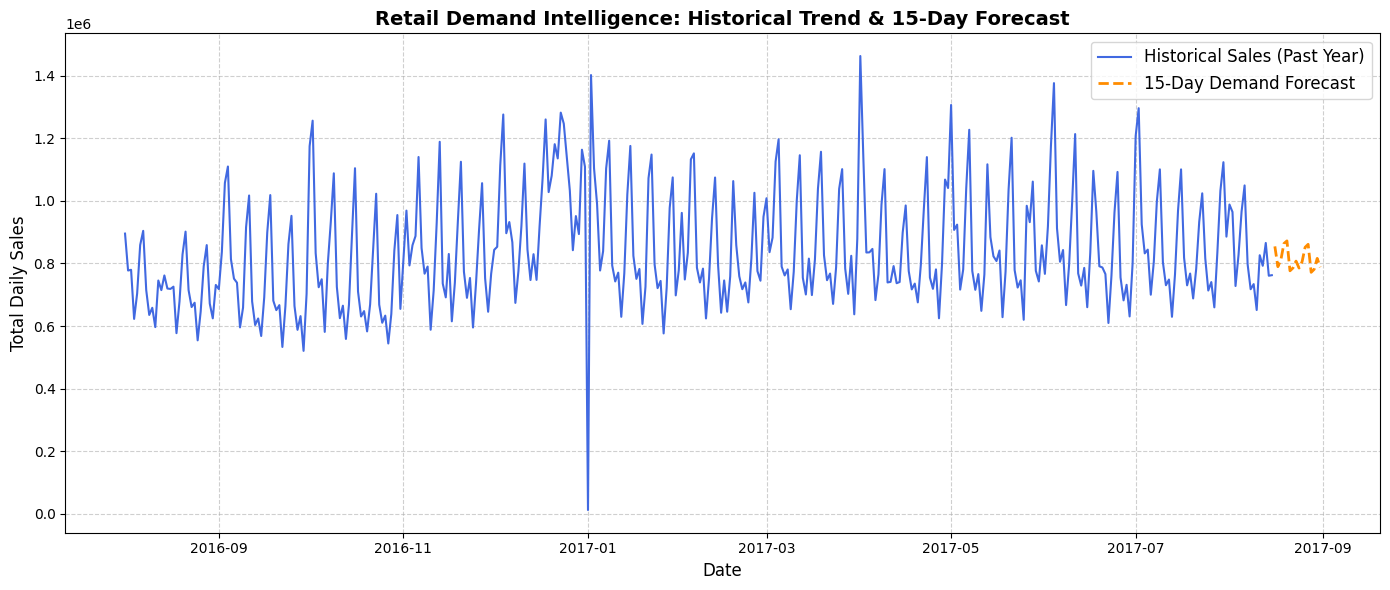

Business Visualization generated successfully!


In [46]:
print("--- Starting Phase 10: Business Visualization & Story ---")
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure reports/figures exists
_fig_dir = Path("../reports/figures")
if not _fig_dir.exists():
    _fig_dir = Path("reports/figures")
_fig_dir.mkdir(parents=True, exist_ok=True)

# 1. Aggregate historical daily sales up to the end of training
history_trend = train_df.groupby('date')['sales'].sum().reset_index()

# 2. Aggregate our test predictions by date to visualize the 15-day forecast horizon
test_pred_vis = test_df[['date', 'id']].copy()
# Use correct variable: test_preds_recursive preferred, fallback to test_preds
_forecast_vals = test_preds_recursive if 'test_preds_recursive' in globals() else test_preds if 'test_preds' in globals() else None
if _forecast_vals is not None:
    test_pred_vis['forecast_sales'] = _forecast_vals
    forecast_trend = test_pred_vis.groupby('date')['forecast_sales'].sum().reset_index()
else:
    # fallback empty
    forecast_trend = test_pred_vis.groupby('date').size().reset_index(name='forecast_sales')
    forecast_trend['forecast_sales'] = 0

# 3. Plotting the Past -> Trend -> Forecast story
plt.figure(figsize=(14, 6))

# Plot historical sales (showing the last year for clarity: 2016-2017)
recent_history = history_trend[history_trend['date'] >= '2016-08-01']
plt.plot(recent_history['date'], recent_history['sales'], label='Historical Sales (Past Year)', color='royalblue', linewidth=1.5)

# Plot forecasted sales
plt.plot(forecast_trend['date'], forecast_trend['forecast_sales'], label='15-Day Demand Forecast', color='darkorange', linewidth=2, linestyle='--')

plt.title('Retail Demand Intelligence: Historical Trend & 15-Day Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Sales', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(_fig_dir / "future_forecast.png", dpi=150, bbox_inches='tight')
plt.show()

print("Business Visualization generated successfully!")


--- Generating Final Visual Story ---


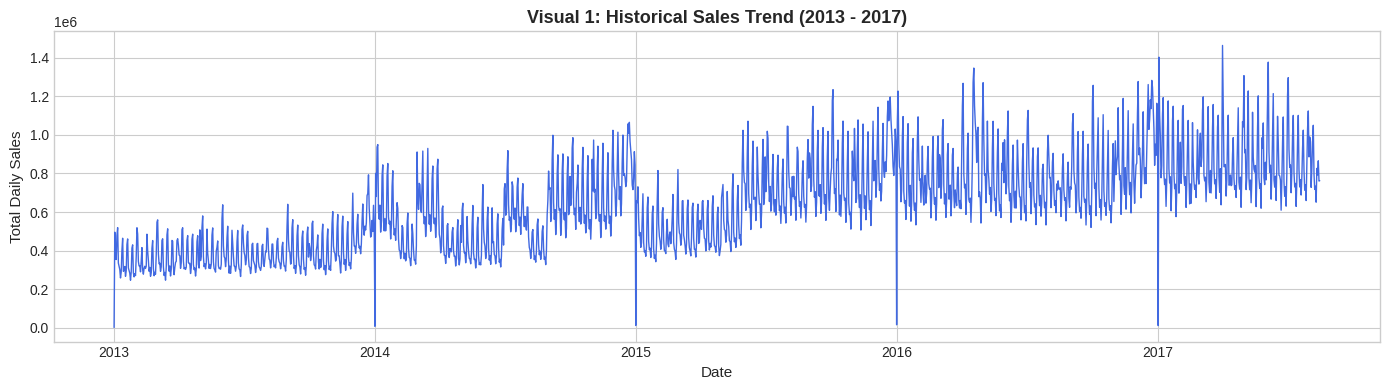

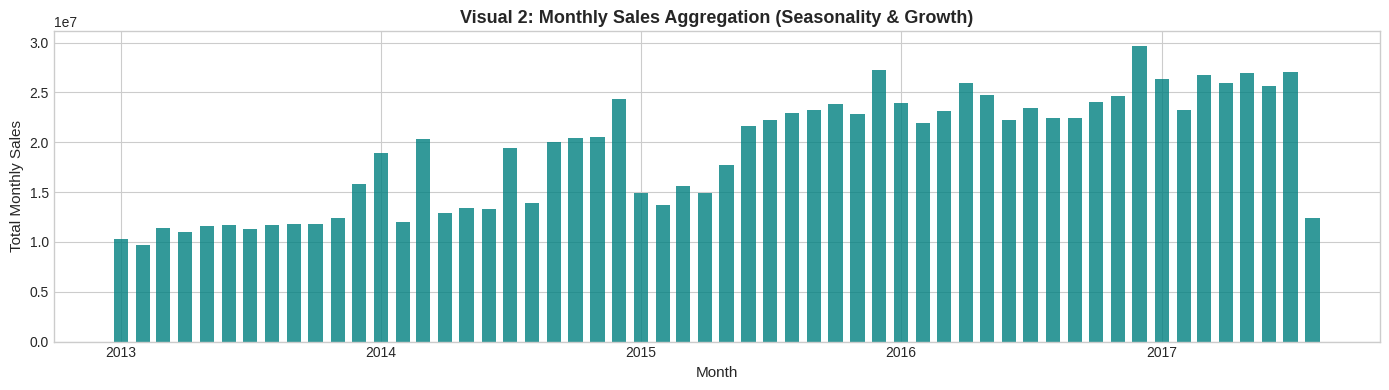

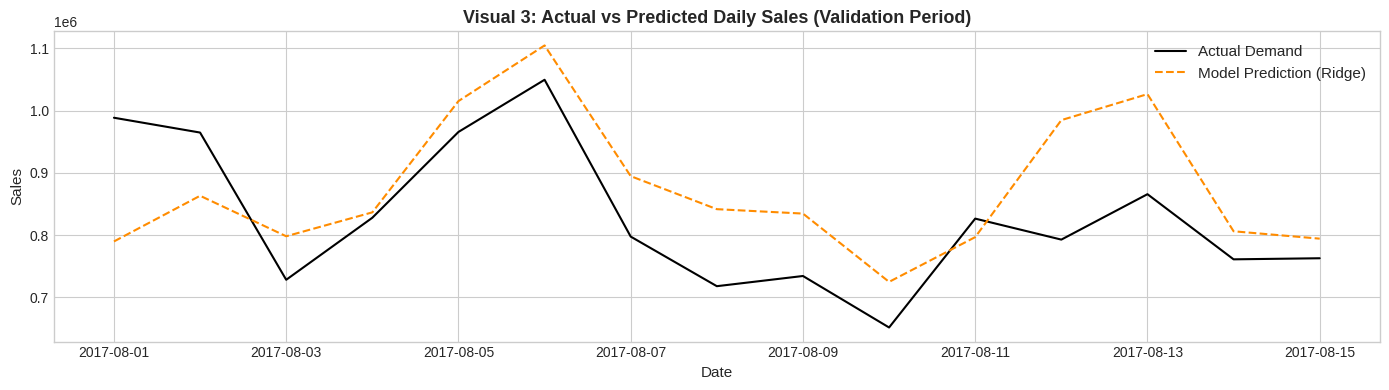

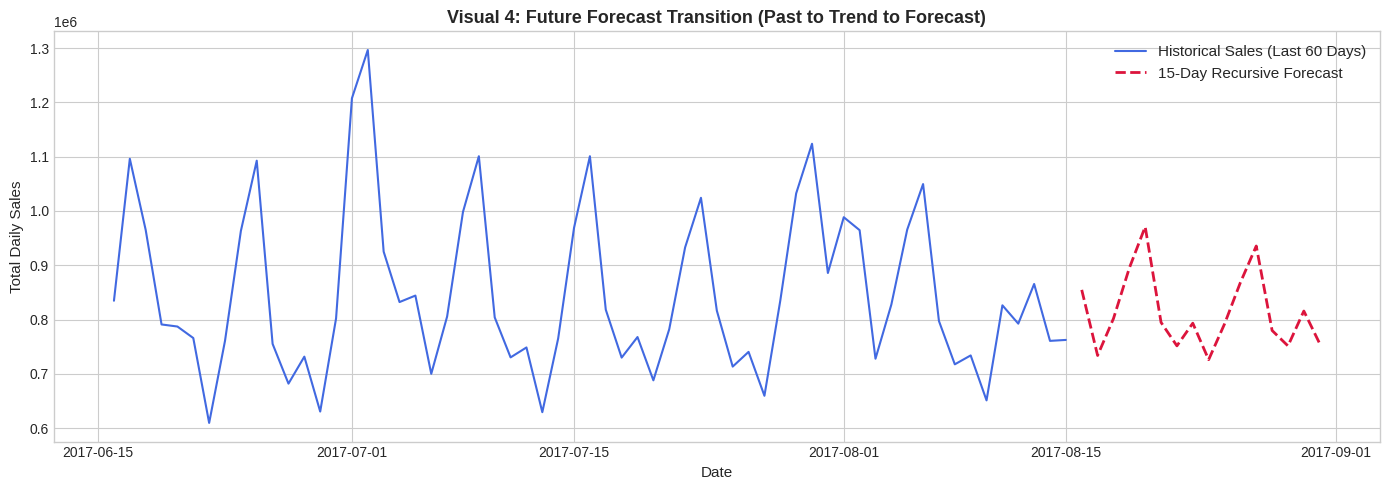

--- Final Visual Story Complete ---


In [50]:
print("--- Generating Final Visual Story For Bussiness ---")
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure reports/figures exists (works from notebooks/ or project root)
_fig_dir = Path("../reports/figures")
if not _fig_dir.exists():
    _fig_dir = Path("reports/figures")
_fig_dir.mkdir(parents=True, exist_ok=True)

# Set overall plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# -------------------------------------------------------------
# Visual 1 — Historical Sales Trend (What happened?)
# -------------------------------------------------------------
daily_sales = train_df.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(daily_sales['date'], daily_sales['sales'], color='royalblue', linewidth=1)
plt.title('Visual 1: Historical Sales Trend (2013 - 2017)', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Daily Sales', fontsize=11)
plt.tight_layout()
plt.savefig(_fig_dir / "historical_sales.png", dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------
# Visual 2 — Monthly Sales (What pattern exists?)
# -------------------------------------------------------------
train_df['year_month'] = train_df['date'].dt.to_period('M')
monthly_sales = train_df.groupby('year_month')['sales'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].dt.to_timestamp()

plt.figure(figsize=(14, 4))
plt.bar(monthly_sales['year_month'], monthly_sales['sales'], width=20, color='teal', alpha=0.8)
plt.title('Visual 2: Monthly Sales Aggregation (Seasonality & Growth)', fontsize=13, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Total Monthly Sales', fontsize=11)
plt.tight_layout()
plt.savefig(_fig_dir / "monthly_sales.png", dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------
# Visual 3 — Actual vs Predicted (How well can we predict it?)
# -------------------------------------------------------------
val_agg = val_eval.groupby('date')[['sales', 'pred_ridge']].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(val_agg['date'], val_agg['sales'], label='Actual Demand', color='black', linewidth=1.5)
plt.plot(val_agg['date'], val_agg['pred_ridge'], label='Model Prediction (Ridge)', color='darkorange', linewidth=1.5, linestyle='--')
plt.title('Visual 3: Actual vs Predicted Daily Sales (Validation Period)', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Sales', fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(_fig_dir / "actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------
# Visual 4 — Future Forecast (What happens next?)
# -------------------------------------------------------------
# Show the last 60 historical days leading straight into the 15-day forecast horizon
recent_history = daily_sales[daily_sales['date'] >= (daily_sales['date'].max() - pd.Timedelta(days=60))]

test_pred_vis = test_df[['date', 'id']].copy()
test_pred_vis['forecast_sales'] = test_preds_recursive
forecast_trend = test_pred_vis.groupby('date')['forecast_sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(recent_history['date'], recent_history['sales'], label='Historical Sales (Last 60 Days)', color='royalblue', linewidth=1.5)
plt.plot(forecast_trend['date'], forecast_trend['forecast_sales'], label='15-Day Recursive Forecast', color='crimson', linewidth=2, linestyle='--')
plt.title('Visual 4: Future Forecast Transition (Past to Trend to Forecast)', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Daily Sales', fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(_fig_dir / "future_forecast.png", dpi=150, bbox_inches='tight')
plt.show()

print("--- Final Visual Story Complete ---")


In [49]:
# Final Submission Validation

print("Submission shape:", submission.shape)

# 1. Correct number of rows
assert len(submission) == len(test_df), \
    "Submission row count does not match test.csv"

# 2. Correct columns
assert list(submission.columns) == ['id', 'sales'], \
    "Submission columns are incorrect"

# 3. IDs match exactly and in the same order
assert submission['id'].equals(test_df['id']), \
    "Submission IDs/order do not match test.csv"

# 4. No missing predictions
assert submission['sales'].isna().sum() == 0, \
    "Submission contains missing predictions"

# 5. No negative predictions
assert (submission['sales'] < 0).sum() == 0, \
    "Submission contains negative predictions"

print("\nâœ… Submission validation passed")
print("Rows:", len(submission))
print("Missing predictions:", submission['sales'].isna().sum())
print("Negative predictions:", (submission['sales'] < 0).sum())
print("ID order verified: âœ…")
submission.to_csv('submission.csv', index=False)

print("Final submission saved successfully.")

Submission shape: (28512, 2)

âœ… Submission validation passed
Rows: 28512
Missing predictions: 0
Negative predictions: 0
ID order verified: âœ…
Final submission saved successfully.
